In [1]:
import seaborn as sns 
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

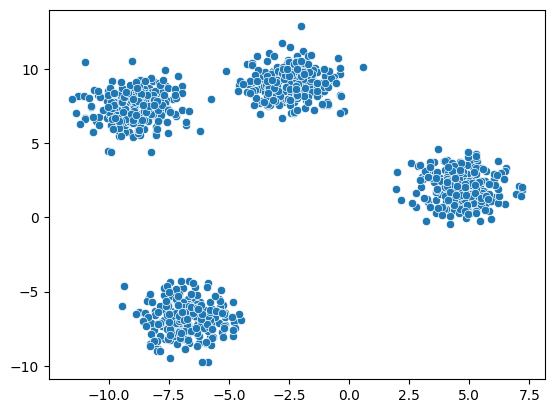

In [3]:
# Visulize
sns.scatterplot(x=X[:, 0], y=X[:, 1])

In [4]:
# K-Means Clustring
from sklearn.cluster import KMeans

In [11]:
k = 4 

kmeans = KMeans(
    n_clusters=k,
    random_state=42
)

In [14]:
labels = kmeans.fit_predict(X)

<Axes: >

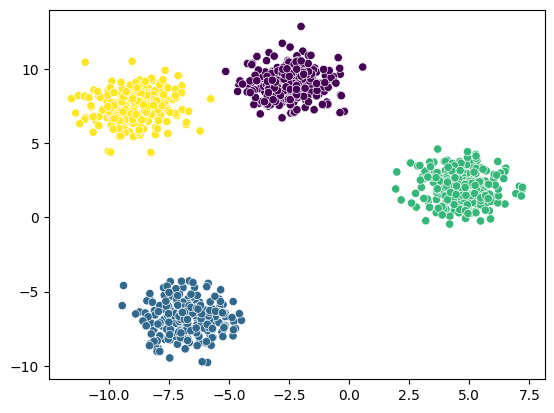

In [16]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], c=labels)

Choose our K value-elbow;silhouette score

In [17]:
# Elbow Method 

wcss = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

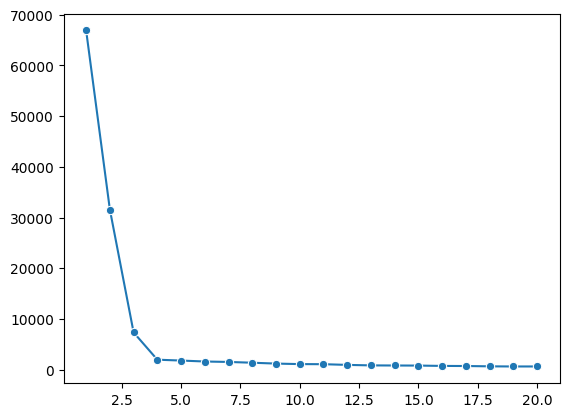

In [19]:
sns.lineplot(x=range(1, 21), y=wcss, marker='o')

In [21]:
# Kneed Module

!python -m pip install kneed


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Devendra kachhawa\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [22]:
from kneed import KneeLocator

In [24]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")

In [25]:
print("optimal k =",knee.elbow)

optimal k = 4


Silhouette Score

In [26]:
from sklearn.metrics import silhouette_score

In [27]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

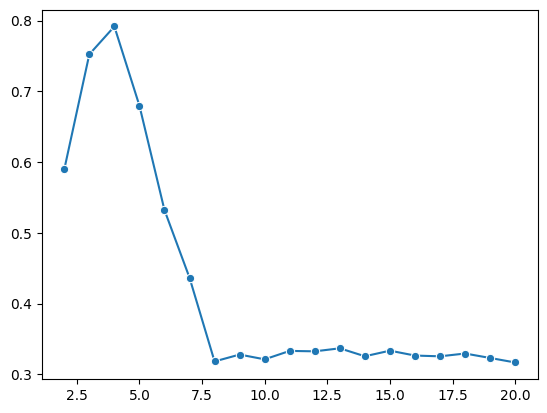

In [28]:
# plot -k and ss

sns.lineplot(x=range(2,21), y=ss, marker='o')